In [1]:
library(Seurat)
library(gridExtra)
library(future)
library(ggplot2)
library(SingleCellExperiment)
library(scater)

plan("multicore", workers = 24)
options(future.globals.maxSize = 100000 * 1024^3)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSe

In [2]:
rna <- readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/ascites_case/seurat_mnn-integration_malignant-cells_primary-tumor_AC-OPC_first-prettx.rds')
rna

An object of class Seurat 
25657 features across 2478 samples within 1 assay 
Active assay: RNA (25657 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: mnn, pca, umap

In [7]:
rna$celltype <- factor(rna$celltype, levels = c('OPC-like', 'AC-like', 'RG-like'))

In [8]:
library(readxl)
file_path <- "/projects/0/einf2548/cruiz/dmg/notebooks/nmf/data/Venkataramani_ Invasiveness_signature.xlsx"
data <- read_excel(file_path, sheet = "Tab 2-Supplementary Table 2a")
data

Gene,S24_statistic,S24_parameter,S24_p.value,S24-correlation coefficient estimate,S24_null.value,S24_alternative,S24_method,P3XX_statistic,P3XX_parameter,⋯,P3XX_alternative,P3XX_method,T269_statistic,T269_parameter,T269_p.value,T269-correlation coefficient estimate,T269_null.value,T269_alternative,T269_method,Direction
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
AC114730.3,-27.5361968,15627,4.913516e-163,-0.215118384,0,two.sided,Pearson's product-moment correlation,-13.971037,3013,⋯,two.sided,Pearson's product-moment correlation,-7.993750,17176,1.391466e-15,-0.06088119,0,two.sided,Pearson's product-moment correlation,Anticorrelated
ACAT2,26.3135178,15627,2.361662e-149,0.205980829,0,two.sided,Pearson's product-moment correlation,18.847910,3013,⋯,two.sided,Pearson's product-moment correlation,8.610422,17176,7.900615e-18,0.06555837,0,two.sided,Pearson's product-moment correlation,Correlated
ACTB,30.6877422,15627,7.185270e-201,0.238407673,0,two.sided,Pearson's product-moment correlation,19.693504,3013,⋯,two.sided,Pearson's product-moment correlation,28.315011,17176,2.017107e-172,0.21117825,0,two.sided,Pearson's product-moment correlation,Correlated
ANAPC11,39.2248617,15627,0.000000e+00,0.299386392,0,two.sided,Pearson's product-moment correlation,23.380055,3013,⋯,two.sided,Pearson's product-moment correlation,13.202385,17176,1.325460e-39,0.10023026,0,two.sided,Pearson's product-moment correlation,Correlated
ANXA2,69.2794039,15627,0.000000e+00,0.484736496,0,two.sided,Pearson's product-moment correlation,1.471536,3013,⋯,two.sided,Pearson's product-moment correlation,31.274489,17176,7.163232e-209,0.23211486,0,two.sided,Pearson's product-moment correlation,Correlated
AP2S1,31.2547087,15627,4.612903e-208,0.242555410,0,two.sided,Pearson's product-moment correlation,13.519309,3013,⋯,two.sided,Pearson's product-moment correlation,9.552745,17176,1.428953e-21,0.07269701,0,two.sided,Pearson's product-moment correlation,Correlated
ASCL1,-35.0028125,15627,1.738642e-258,-0.269634015,0,two.sided,Pearson's product-moment correlation,-11.623998,3013,⋯,two.sided,Pearson's product-moment correlation,-18.456694,17176,2.464027e-75,-0.13945317,0,two.sided,Pearson's product-moment correlation,Anticorrelated
ASPM,-7.9323265,15627,2.295602e-15,-0.063327186,0,two.sided,Pearson's product-moment correlation,13.879732,3013,⋯,two.sided,Pearson's product-moment correlation,33.972231,17176,6.804857e-245,0.25092360,0,two.sided,Pearson's product-moment correlation,Correlated
ATF3,33.9898968,15627,2.254784e-244,0.262375897,0,two.sided,Pearson's product-moment correlation,5.873370,3013,⋯,two.sided,Pearson's product-moment correlation,31.123962,17176,6.127660e-207,0.23105744,0,two.sided,Pearson's product-moment correlation,Correlated


In [9]:
invasiveness_sig <- list(data$Gene)
invasiveness_sig

[[1]]
  [1] "AC114730.3"  "ACAT2"       "ACTB"        "ANAPC11"     "ANXA2"      
  [6] "AP2S1"       "ASCL1"       "ASPM"        "ATF3"        "ATP1B3"     
 [11] "AURKA"       "AURKAIP1"    "AURKB"       "B2M"         "BCAN"       
 [16] "BCL7C"       "BIRC5"       "BTG1"        "BUB1"        "BUD31"      
 [21] "CALM1"       "CALM2"       "CASC5"       "CCDC109B"    "CCNA2"      
 [26] "CDCA3"       "CDK1"        "CDKN3"       "CENPA"       "CENPF"      
 [31] "CENPK"       "CFL1"        "CHCHD2"      "CHCHD3"      "CKAP2"      
 [36] "CKS1B"       "CLIC1"       "CLU"         "CNN3"        "COPRS"      
 [41] "COX5A"       "COX8A"       "CRYAB"       "CTNNAL1"     "CYR61"      
 [46] "DCX"         "DLGAP5"      "DLL1"        "DLL3"        "DNAJB1"     
 [51] "DNPH1"       "DTYMK"       "ECI1"        "EEF1B2"      "ETFB"       
 [56] "ETV1"        "FAM64A"      "FAM83D"      "FBXO5"       "FDPS"       
 [61] "FIBP"        "GAPDH"       "GFAP"        "GNB2"        "GPX4"       
 [66] "GSTP1"       "GTSE1"       "H2AFZ"       "HES6"        "HINT1"      
 [71] "HINT2"       "HIST1H4C"    "HJURP"       "HMGB2"       "HOPX"       
 [76] "ITGB1BP1"    "KCNQ1OT1"    "KIAA0101"    "KIF20A"      "KIF23"      
 [81] "KIF2C"       "KIFC1"       "KPNA2"       "LINC00152"   "LMNB1"      
 [86] "LRRN1"       "LSMD1"       "MAD2L1"      "MALAT1"      "MANF"       
 [91] "MARCKSL1"    "MEA1"        "MFNG"        "MIR4435-1HG" "MKI67"      
 [96] "MRPL37"      "MT-ND3"      "MT2A"        "MXD3"        "MYC"        
[101] "MZT2B"       "NCAPG"       "NDC80"       "NDUFA4"      "NDUFA6"     
[106] "NDUFS8"      "NEK2"        "NEU4"        "NGFRAP1"     "NMB"        
[111] "NUF2"        "NUSAP1"      "OLIG1"       "PBK"         "PCOLCE"     
[116] "PFN1"        "PHF19"       "PHPT1"       "PKM"         "POLR2I"     
[121] "PPIA"        "PRC1"        "PRR24"       "PSMA7"       "PSMB3"      
[126] "PSME2"       "PTN"         "PTTG1"       "PXMP2"       "RACGAP1"    
[131] "RBX1"        "RDX"         "RRM2"        "SGOL1"       "SGOL2"      
[136] "SHD"         "SHMT2"       "SIVA1"       "SLC25A5"     "SMC4"       
[141] "SOCS3"       "SOX4"        "SPARC"       "SPC25"       "SSBP4"      
[146] "STK17A"      "TAGLN2"      "TCF12"       "TCTEX1D2"    "TECR"       
[151] "TK1"         "TMEM147"     "TMEM54"      "TNFRSF12A"   "TNK2"       
[156] "TOP2A"       "TPI1"        "TPX2"        "TUBA1B"      "TUBA1C"     
[161] "TUBB2A"      "TUBB6"       "UBE2C"       "UBE2T"       "UQCC2"      
[166] "UQCR10"      "UQCRC1"      "UQCRQ"       "VIM"         "VMP1"       
[171] "ZFP36"       "ZWINT"

In [10]:
rna <- UCell::AddModuleScore_UCell(
    obj = rna,
    features = invasiveness_sig,
    ncores = 12,
    name = 'invasiveness'
    )

Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* AC114730.3,CASC5,CCDC109B,CYR61,FAM64A,KCNQ1OT1,KIAA0101,LINC00152,LSMD1,MALAT1,MIR4435-1HG,MT-ND3,NGFRAP1,PRR24,SGOL1,SGOL2”


In [11]:
MP_list = readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/nmf/data/robust_NMF_programs_malignant_nomt_noribo.rds')

In [12]:
MP_list

MP_1,MP_2,MP_3,MP_4,MP_5,MP_6,MP_7,MP_8,MP_9,MP_10,MP_11,MP_12,MP_13
DIAPH3,CA10,SPARCL1,FTL,BCAS1,VEGFA,GAP43,DNAH6,CD44,HSPH1,SLIT1,KCNH7,CHI3L1
RRM2,MMP16,CLU,FTH1,SIRT2,HILPDA,CAMK2D,MAP3K19,ACTN1,HSPE1,CHD7,SRRM4,GALNT15
TOP2A,PCDH15,DCLK1,EEF1A1,PKP4,SLC6A6,ITGA3,ARMC3,ELL2,USPL1,EGFR,STMN2,NNMT
CENPF,LHFPL3,AQP4,TMSB10,MBP,FAM162A,ADAMTS9,CFAP43,GAP43,CHORDC1,GLCCI1,ELAVL4,ABCA8
ASPM,NXPH1,EEPD1,GAPDH,BMPER,NDRG1,HIVEP3,DNAH9,HRH1,HSPD1,GRIK2,MYT1L,ANXA1
KNL1,SEZ6L,KCNN3,MIF,CDK18,PDK1,EMP1,C6ORF118,LPAR1,DNAJB1,HES6,NYAP2,C3
TPX2,DSCAM,ANOS1,TMSB4X,SHROOM4,INSIG2,GALR1,VWA3A,NAMPT,HSP90AA1,NKD1,RIT2,CP
BRIP1,PDGFRA,SLC4A4,B2M,ST18,SLC2A1,RASSF8,ZBBX,CLIC4,HSP90AB1,PAK3,RND3,MGST1
KIF14,FGF12,DAAM2,PTMA,MYRF,GBE1,RGS17,SPATA17,OSMR,HSPA1A,SEZ6L,CELF4,SPARCL1
NUSAP1,OPCML,APOE,ATP5F1E,PPP1R16B,AKAP12,SPOCD1,ADGB,SAMD4A,HSPA1B,BEST3,CNTNAP5,APOE


In [22]:
list(MP_list[,6])

[[1]]
 [1] "VEGFA"   "HILPDA"  "SLC6A6"  "FAM162A" "NDRG1"   "PDK1"    "INSIG2" 
 [8] "SLC2A1"  "GBE1"    "AKAP12"  "ERO1A"   "HK2"     "PGK1"    "PLOD2"  
[15] "PFKFB4"  "BNIP3L"  "EGLN3"   "BNIP3"   "PFKP"    "PRELID2" "IGFBP5" 
[22] "AK4"     "SORCS3"  "ADM"     "PCBP3"   "SLC2A3"  "CDON"    "DNAH11" 
[29] "EPAS1"   "KDM3A"   "ENO1"    "ITPR1"   "TMEM45A" "DDIT4"   "EGLN1"  
[36] "GAPDH"   "P4HA1"   "PPFIA4"  "PRKCB"   "ADCY8"   "C4ORF47" "CA12"   
[43] "CLEC2B"  "ENO2"    "FAM210A" "IGFBP2"  "NGLY1"   "CDK19"   "CA9"    
[50] "ZNF395"

In [25]:
rna <- UCell::AddModuleScore_UCell(
    obj = rna,
    features = list(MP_list[,6]),
    ncores = 12,
    name = 'hypoxia'
    )

Warning message:
“The following genes were not found and will be
                        imputed to exp=0:
* C4ORF47”


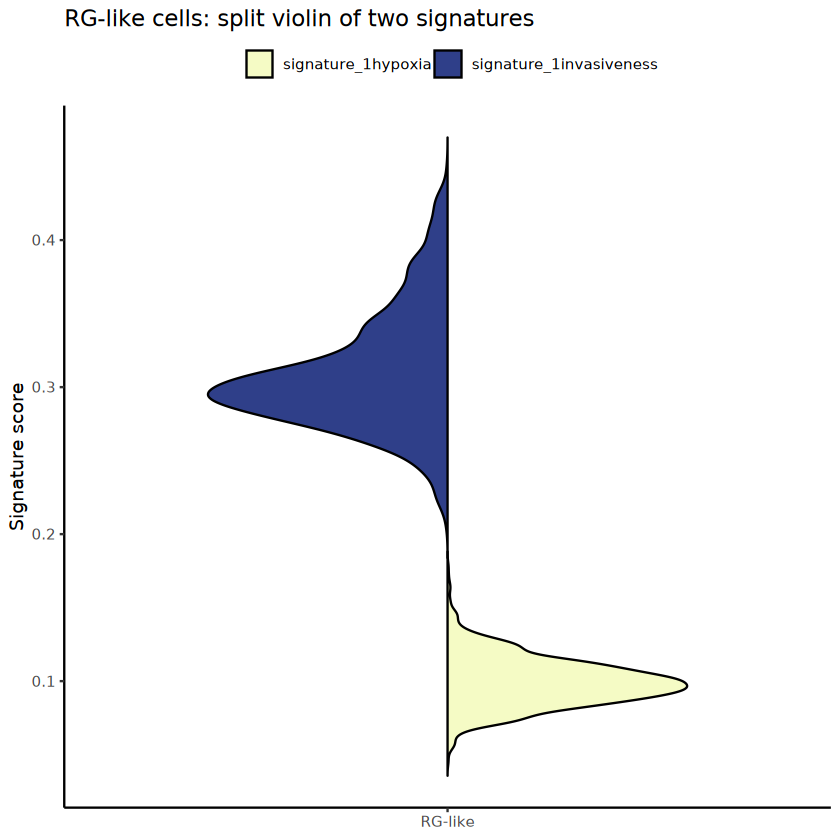

In [37]:
# install.packages("gghalves")  # if needed

library(dplyr)
library(tidyr)
library(ggplot2)
library(gghalves)

# 1) Long-format data, keep only RG-like
df <- rna@meta.data %>%
  filter(celltype == "RG-like") %>%
  select(celltype, signature_1invasiveness, signature_1hypoxia) %>%
  pivot_longer(
    c(signature_1invasiveness, signature_1hypoxia),
    names_to = "signature",
    values_to = "score"
  )

# 2) Split into left/right halves
df_left  <- df %>% filter(signature == "signature_1invasiveness")
df_right <- df %>% filter(signature == "signature_1hypoxia")

# Optional: colors for the two signatures
sig_cols <- c(
  signature_1invasiveness = "#192a7c",
  signature_1hypoxia      = "#f3fabe"
)

# 3) Draw split (half) violin for the single group RG-like
ggplot() +
  gghalves::geom_half_violin(
    data = df_left,
    aes(x = celltype, y = score, fill = signature),
    side = "l", trim = FALSE, color = "black", alpha = 0.9
  ) +
  gghalves::geom_half_violin(
    data = df_right,
    aes(x = celltype, y = score, fill = signature),
    side = "r", trim = FALSE, color = "black", alpha = 0.9
  ) +
  scale_fill_manual(values = sig_cols, name = NULL) +
  labs(x = NULL, y = "Signature score",
       title = "RG-like cells: split violin of two signatures") +
  theme_classic() +
  theme(legend.position = "top")

In [38]:
ggsave('figures/RG_ascites_invasiveness_hypoxia_signatures.pdf', height = 5, width = 2)